# Ionization parameter maps: [S III]/[S II] and [O III]/[O II] compared

Same MaNGA `LOGCUBE` and slicing/masking methodology as `showcase_cube.ipynb`, applied to
Kewley & Dopita (2002)'s two ionization-parameter diagnostics:

- [S III] λλ9069,9532 / [S II] λλ6717,31 (their Fig. 2 / Table 2 bottom block),
- [O III] λ5007 / [O II] λλ3726,29 (their Fig. 1 / Table 2 top block).

Intermediate visualisations from the source notebook are dropped; only the final `log U` maps
(one per diagnostic, side-by-side) and their difference are plotted.

For each spaxel we

1. sum the flux in narrow windows around each emission line (skipping voxels flagged by `MASK`),
2. form the diagnostic line ratio,
3. pick the K&D02 metallicity column nearest the [N II]/[O II] N2O2 estimate for that spaxel,
4. invert the cubic  R = k0 + k1·x + k2·x² + k3·x³  for x = log10(q),
5. convert to the dimensionless ionization parameter  log U = log q − log c.

In [1]:
from astropy.io import fits
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

CUBE_PATH = Path(r"C:\Users\achun\manga-data-pipeline\data\manga-11019-12701-LOGCUBE.fits")

hdul = fits.open(CUBE_PATH)
hdul.info()

Filename: C:\Users\achun\manga-data-pipeline\data\manga-11019-12701-LOGCUBE.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      75   ()      
  1  FLUX          1 ImageHDU       100   (72, 72, 4563)   float32   
  2  IVAR          1 ImageHDU        17   (72, 72, 4563)   float32   
  3  MASK          1 ImageHDU        17   (72, 72, 4563)   int32   
  4  LSFPOST       1 ImageHDU        11   (72, 72, 4563)   float32   
  5  LSFPRE        1 ImageHDU        11   (72, 72, 4563)   float32   
  6  WAVE          1 ImageHDU         9   (4563,)   float64   
  7  SPECRES       1 ImageHDU         9   (4563,)   float64   
  8  SPECRESD      1 ImageHDU         9   (4563,)   float64   
  9  PRESPECRES    1 ImageHDU         9   (4563,)   float64   
 10  PRESPECRESD    1 ImageHDU         9   (4563,)   float64   
 11  OBSINFO       1 BinTableHDU    148   9R x 65C   [26A, 17A, 5A, J, I, 8A, E, E, E, E, E, E, J, J, I, J, E, 12A, J, 8A, E, E, E, E, E, E, E

In [2]:
# MaNGA LOGCUBE HDUs: FLUX (nw, ny, nx), IVAR, MASK, WAVE (nw,)
flux = hdul["FLUX"].data
ivar = hdul["IVAR"].data
mask = hdul["MASK"].data
wave = hdul["WAVE"].data

flux_header = hdul["FLUX"].header
print(f"FLUX shape: {flux.shape}  (wavelength, y, x)")
print(f"WAVE range: {wave[0]:.2f} – {wave[-1]:.2f} {flux_header.get('CUNIT3', 'Angstrom')}")
print(f"Units: {flux_header.get('BUNIT', 'unknown')}")

FLUX shape: (4563, 72, 72)  (wavelength, y, x)
WAVE range: 3621.60 – 10353.81 Angstrom
Units: 1E-17 erg/s/cm^2/Angstrom/spaxel


In [3]:
# Same MASK-aware line-window summation used for [O II]/[N II] in showcase_cube.ipynb,
# now applied to the four lines of the K&D02 [S III]/[S II] diagnostic and to the
# [N II] & [O II] lines used to seed the metallicity guess.

def line_map(wave_lo, wave_hi):
    sl = (wave >= wave_lo) & (wave <= wave_hi)
    if sl.sum() == 0:
        raise ValueError(f"no channels in window {wave_lo}-{wave_hi} A")
    chunk = np.where(mask[sl] == 0, flux[sl], 0.0)
    spaxel_bad = np.any(mask[sl] != 0, axis=0)
    return chunk.sum(axis=0), spaxel_bad, sl.sum()

# metallicity seed: [N II] 6584 and [O II] 3726,29
oii_map,  bad_oii,  n_oii  = line_map(3726.0, 3729.0)
nii_map,  bad_nii,  n_nii  = line_map(6582.0, 6586.0)

# ionization-parameter diagnostics:
#   * [S II] 6717,31 and [S III] 9069, 9532
#   * [O III] 5007 (paired with the [O II] 3726,29 map already computed)
sii_map,   bad_sii,   n_sii   = line_map(6714.0, 6734.0)
siii_a,    bad_siii_a, n_siii_a = line_map(9066.0, 9072.0)
siii_b,    bad_siii_b, n_siii_b = line_map(9529.0, 9535.0)
siii_map   = siii_a + siii_b
bad_siii   = bad_siii_a | bad_siii_b

oiii_map,  bad_oiii,  n_oiii  = line_map(5005.0, 5009.0)

print(f"channels used  [O II]: {n_oii}   [N II]: {n_nii}   [O III] 5007: {n_oiii}")
print(f"channels used  [S II] 6717/31: {n_sii}")
print(f"channels used  [S III] 9069:  {n_siii_a}   [S III] 9532: {n_siii_b}")
print(f"spaxels with any masked voxel  [O III]: {bad_oiii.sum()}  [S II]: {bad_sii.sum()}  [S III]: {bad_siii.sum()}")

channels used  [O II]: 3   [N II]: 3   [O III] 5007: 3
channels used  [S II] 6717/31: 13
channels used  [S III] 9069:  3   [S III] 9532: 3
spaxels with any masked voxel  [O III]: 2425  [S II]: 2421  [S III]: 2423


In [4]:
# Metallicity seed via K&D02 [N II]/[O II] N2O2 calibration (eq. 5).
# Same treatment of divide-by-zero as in showcase_cube.ipynb; log is base-10 (paper eq. 5 uses log10).
with np.errstate(divide="ignore", invalid="ignore"):
    R_n2o2 = np.log10(nii_map / oii_map)
R_n2o2 = np.nan_to_num(R_n2o2, nan=0.0, posinf=0.0, neginf=0.0)

with np.errstate(invalid="ignore"):
    OH = np.log10(1.54020 + 1.26602 * R_n2o2 + 0.167977 * R_n2o2**2) + 8.93
OH = np.nan_to_num(OH, nan=0.0, posinf=0.0, neginf=0.0)

# K&D02 eq. 5 is only calibrated for 12+log(O/H) >= 8.6; flag anything outside
oh_ok = (OH >= 8.4) & ~(bad_oii | bad_nii)
print(f"OH map shape: {OH.shape}  valid spaxels: {oh_ok.sum()}/{OH.size}")

OH map shape: (72, 72)  valid spaxels: 2637/5184


In [5]:
# Line ratio for the ionization-parameter diagnostic (K&D02 Fig. 2 / eq. 3).
with np.errstate(divide="ignore", invalid="ignore"):
    R_siii_sii = np.log10(siii_map / sii_map)
R_siii_sii_finite = np.isfinite(R_siii_sii)
R_siii_sii = np.where(R_siii_sii_finite, R_siii_sii, np.nan)

print(f"log([S III]/[S II])  min/median/max: "
      f"{np.nanmin(R_siii_sii):.2f} / {np.nanmedian(R_siii_sii):.2f} / {np.nanmax(R_siii_sii):.2f}")

log([S III]/[S II])  min/median/max: -3.65 / -0.40 / 2.07


In [6]:
# Kewley & Dopita (2002) Table 2 -- cubic fit  R = k0 + k1*x + k2*x^2 + k3*x^3
# with R = log10([S III] 9069+9532 / [S II] 6717+31) and x = log10(q [cm/s]).
# One coefficient column per metallicity Z/Zsun.

KD02_Z    = np.array([0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0, 3.0])
KD02_OH   = np.array([7.6,  7.9, 8.2, 8.6, 8.9, 9.1, 9.2, 9.4])  # 12+log(O/H) columns from paper
KD02_COEF = np.array([
    # k0            k1           k2            k3
    [ 30.0116,  -14.8970,     2.30577,  -0.112314 ],   # Z=0.05
    [ 16.8569,   -9.62876,    1.59938,  -0.0804552],   # Z=0.1
    [ 32.2358,  -15.2438,     2.27251,  -0.106913 ],   # Z=0.2
    [ -3.06247,  -0.864092,   0.328467, -0.0196089],   # Z=0.5
    [ -2.94394,  -0.546041,   0.239226, -0.0136716],   # Z=1.0
    [-38.1338,   13.0914,    -1.51014,   0.0605926],   # Z=1.5
    [-21.0240,    6.55748,   -0.683584,  0.0258690],   # Z=2.0
    [ -6.61131,   1.36836,   -0.0717560, 0.00225792],  # Z=3.0
])

# Build a lookup table  R_curve[iZ, ix]  on a dense log(q) grid, then invert per spaxel
# by picking the metallicity column nearest OH and interpolating R -> log q.
# The K&D02 grid runs q in [5e6, 3e8] cm/s, i.e. log q in [~6.7, ~8.48].
logq_grid = np.linspace(6.7, 8.5, 2001)
R_curve   = (KD02_COEF[:, 0][:, None]
             + KD02_COEF[:, 1][:, None] * logq_grid
             + KD02_COEF[:, 2][:, None] * logq_grid**2
             + KD02_COEF[:, 3][:, None] * logq_grid**3)

# Sanity check: curves should be monotonic in log q over the modelled range
mono = np.all(np.diff(R_curve, axis=1) > 0, axis=1) | np.all(np.diff(R_curve, axis=1) < 0, axis=1)
print(f"monotonic curves per Z column: {mono}")
print(f"R_curve at Z=1.0Zsun: min={R_curve[4].min():.3f}  max={R_curve[4].max():.3f}")

monotonic curves per Z column: [False  True  True  True  True  True  True  True]
R_curve at Z=1.0Zsun: min=0.025  max=1.303


In [7]:
# For each spaxel: pick the metallicity column nearest its OH, invert  R = P(log q)
# by interpolating on the pre-computed curve. Spaxels where R falls outside the
# calibrated range or the underlying line map is masked are set to NaN.

# nearest-Z column index per spaxel; use Z=1.0 (index 4) where OH is not reliable
iZ = np.argmin(np.abs(OH[..., None] - KD02_OH), axis=-1)
iZ = np.where(oh_ok, iZ, 4)

logq_map = np.full(R_siii_sii.shape, np.nan)

for iz in range(len(KD02_OH)):
    sel = (iZ == iz) & R_siii_sii_finite & ~(bad_sii | bad_siii)
    if not np.any(sel):
        continue
    curve = R_curve[iz]
    # ensure ascending x for np.interp
    if curve[0] > curve[-1]:
        xp, fp = curve[::-1], logq_grid[::-1]
    else:
        xp, fp = curve, logq_grid
    r = R_siii_sii[sel]
    inside = (r >= xp.min()) & (r <= xp.max())
    out = np.full(r.shape, np.nan)
    out[inside] = np.interp(r[inside], xp, fp)
    logq_map[sel] = out

LOG_C_CGS = np.log10(2.99792458e10)   # cm s^-1
logU_map  = logq_map - LOG_C_CGS

n_valid = np.isfinite(logq_map).sum()
print(f"log q valid spaxels: {n_valid}/{logq_map.size}")
if n_valid:
    print(f"log q  min/median/max: {np.nanmin(logq_map):.2f} / {np.nanmedian(logq_map):.2f} / {np.nanmax(logq_map):.2f}")
    print(f"log U  min/median/max: {np.nanmin(logU_map):.2f} / {np.nanmedian(logU_map):.2f} / {np.nanmax(logU_map):.2f}")

log q valid spaxels: 127/5184
log q  min/median/max: 6.71 / 6.90 / 8.26
log U  min/median/max: -3.77 / -3.58 / -2.21


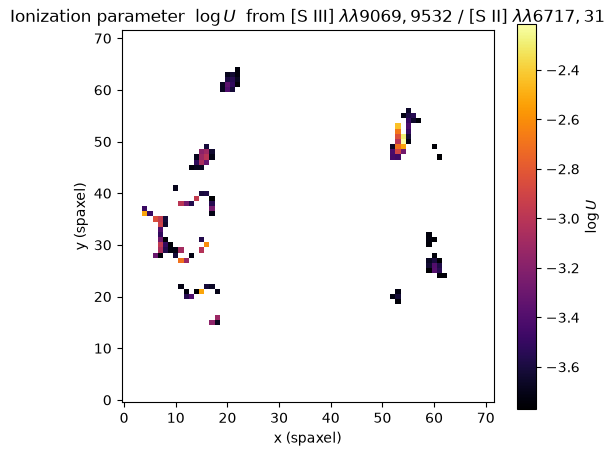

In [8]:
# Final ionization-parameter map.
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(np.ma.masked_invalid(logU_map), origin="lower", cmap="inferno")
ax.set_title(r"Ionization parameter  $\log U$  from [S III] $\lambda\lambda 9069,9532$ / [S II] $\lambda\lambda 6717,31$")
ax.set_xlabel("x (spaxel)")
ax.set_ylabel("y (spaxel)")
fig.colorbar(im, ax=ax, label=r"$\log U$")
plt.show()

## Cross-check: [O III] λ5007 / [O II] λλ3726,29 diagnostic

Same K&D02 machinery as above, but using the top block of Table 2. Unlike [S III]/[S II],
this ratio is strongly metallicity-dependent (K&D02 §3, Fig. 1), so picking the right
metallicity column from the N2O2 seed matters more.

In [9]:
# K&D02 Table 2, top block: cubic coefficients for  R = log10([O III] 5007 / [O II] 3726,29)
# as a function of  x = log10(q [cm/s]),  one column per metallicity Z/Zsun (same OH grid).
KD02_COEF_OIII_OII = np.array([
    # k0            k1           k2            k3
    [-36.9772,   10.2838,   -0.957421,    0.0328614 ],  # Z=0.05
    [-74.2814,   24.6206,   -2.79194,     0.110773  ],  # Z=0.1
    [-36.7948,   10.0581,   -0.914212,    0.0300472 ],  # Z=0.2
    [-81.1880,   27.5082,   -3.19126,     0.128252  ],  # Z=0.5
    [-52.6367,   16.0880,   -1.67443,     0.0608004 ],  # Z=1.0
    [-86.8674,   28.0455,   -3.01747,     0.108311  ],  # Z=1.5
    [-24.4044,    2.51913,   0.452486,   -0.0491711 ],  # Z=2.0
    [ 49.4728,  -27.4711,    4.50304,    -0.232228  ],  # Z=3.0
])

def invert_kd02(R_map, spaxel_ok, coef_table, logq_grid, oh_index):
    """Invert R = k0 + k1 x + k2 x^2 + k3 x^3 for x = log q, one row per spaxel."""
    R_curve = (coef_table[:, 0][:, None]
               + coef_table[:, 1][:, None] * logq_grid
               + coef_table[:, 2][:, None] * logq_grid**2
               + coef_table[:, 3][:, None] * logq_grid**3)
    out = np.full(R_map.shape, np.nan)
    for iz in range(coef_table.shape[0]):
        sel = (oh_index == iz) & np.isfinite(R_map) & spaxel_ok
        if not np.any(sel):
            continue
        curve = R_curve[iz]
        if not (np.all(np.diff(curve) > 0) or np.all(np.diff(curve) < 0)):
            # non-monotonic column (e.g. Z=0.05 SIII/SII): skip, we can't invert with interp
            continue
        if curve[0] > curve[-1]:
            xp, fp = curve[::-1], logq_grid[::-1]
        else:
            xp, fp = curve, logq_grid
        r = R_map[sel]
        inside = (r >= xp.min()) & (r <= xp.max())
        vals = np.full(r.shape, np.nan)
        vals[inside] = np.interp(r[inside], xp, fp)
        out[sel] = vals
    return out, R_curve

# --- [O III] 5007 / [O II] 3726,29 ------------------------------------------------
with np.errstate(divide="ignore", invalid="ignore"):
    R_oiii_oii = np.log10(oiii_map / oii_map)
R_oiii_oii = np.where(np.isfinite(R_oiii_oii), R_oiii_oii, np.nan)

logq_map_o, R_curve_o = invert_kd02(
    R_oiii_oii,
    ~(bad_oii | bad_oiii),
    KD02_COEF_OIII_OII,
    logq_grid,
    iZ,
)
logU_map_o = logq_map_o - LOG_C_CGS

print(f"log([O III]/[O II])  min/median/max: "
      f"{np.nanmin(R_oiii_oii):.2f} / {np.nanmedian(R_oiii_oii):.2f} / {np.nanmax(R_oiii_oii):.2f}")
print(f"R_curve [O III/O II] at Z=1.0Zsun: min={R_curve_o[4].min():.3f}  max={R_curve_o[4].max():.3f}")
n_valid_o = np.isfinite(logq_map_o).sum()
print(f"log q [O III/O II] valid spaxels: {n_valid_o}/{logq_map_o.size}")
if n_valid_o:
    print(f"  log q  min/median/max: {np.nanmin(logq_map_o):.2f} / {np.nanmedian(logq_map_o):.2f} / {np.nanmax(logq_map_o):.2f}")
    print(f"  log U  min/median/max: {np.nanmin(logU_map_o):.2f} / {np.nanmedian(logU_map_o):.2f} / {np.nanmax(logU_map_o):.2f}")

# spaxels where both diagnostics succeed -> useful for a per-spaxel systematic check
both_ok = np.isfinite(logU_map) & np.isfinite(logU_map_o)
if both_ok.any():
    delta = logU_map_o[both_ok] - logU_map[both_ok]
    print(f"overlap spaxels: {both_ok.sum()}   median(logU_OIII/OII - logU_SIII/SII) = {np.median(delta):+.2f} dex")

log([O III]/[O II])  min/median/max: -3.23 / 0.09 / 2.66
R_curve [O III/O II] at Z=1.0Zsun: min=-1.726  max=0.473
log q [O III/O II] valid spaxels: 826/5184
  log q  min/median/max: 6.72 / 7.67 / 8.50
  log U  min/median/max: -3.76 / -2.81 / -1.98
overlap spaxels: 29   median(logU_OIII/OII - logU_SIII/SII) = +0.43 dex


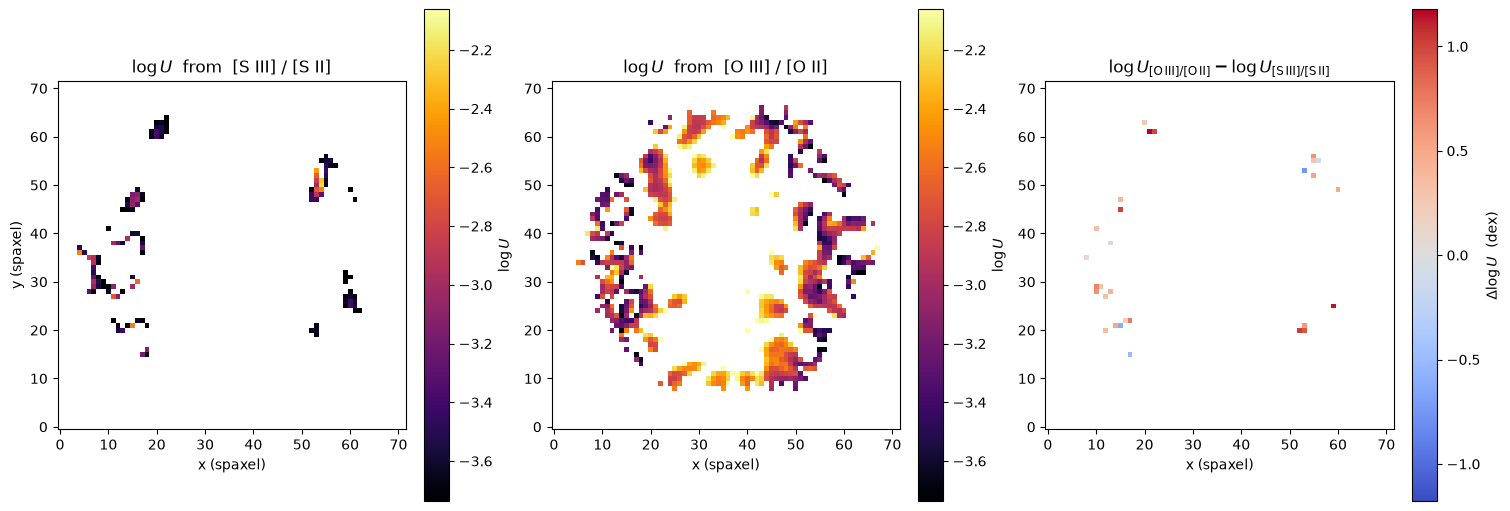

In [10]:
# Side-by-side comparison of the two log(U) maps + their difference.
finite_vals = np.concatenate([
    logU_map[np.isfinite(logU_map)],
    logU_map_o[np.isfinite(logU_map_o)],
])
vmin, vmax = np.percentile(finite_vals, [2, 98]) if finite_vals.size else (-3.8, -2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axes[0].imshow(np.ma.masked_invalid(logU_map), origin="lower",
                     cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title(r"$\log U$  from  [S III] / [S II]")
fig.colorbar(im0, ax=axes[0], label=r"$\log U$")

im1 = axes[1].imshow(np.ma.masked_invalid(logU_map_o), origin="lower",
                     cmap="inferno", vmin=vmin, vmax=vmax)
axes[1].set_title(r"$\log U$  from  [O III] / [O II]")
fig.colorbar(im1, ax=axes[1], label=r"$\log U$")

diff = logU_map_o - logU_map
absmax = np.nanpercentile(np.abs(diff), 98) if np.any(np.isfinite(diff)) else 0.5
im2 = axes[2].imshow(np.ma.masked_invalid(diff), origin="lower",
                     cmap="coolwarm", vmin=-absmax, vmax=absmax)
axes[2].set_title(r"$\log U_{\mathrm{[O\,III]/[O\,II]}} - \log U_{\mathrm{[S\,III]/[S\,II]}}$")
fig.colorbar(im2, ax=axes[2], label=r"$\Delta \log U$  (dex)")

for ax in axes:
    ax.set_xlabel("x (spaxel)")
axes[0].set_ylabel("y (spaxel)")
plt.show()

## Cube mask from metallicity + [O III]/[O II] ionization parameter

Build a boolean mask over the cube that keeps only spaxels satisfying **both**

- **12 + log(O/H) ≥ 8.93**  (solar oxygen abundance on the Anders & Grevesse scale used by
  K&D02 — see their Table 1 log(Z⊙)_O = −3.07, and the +8.93 additive constant in eq. 5), and
- **log U (from [O III]/[O II]) < −2.75**  (i.e. below the middle of the K&D02 model grid,
  which runs `log U ∈ [−3.78, −2.0]`).

Every other spaxel is excluded. The 2-D `include_spaxel` mask is broadcast along the
wavelength axis to produce a `(nw, ny, nx)` cube mask that can be applied to `FLUX`.

In [11]:
SOLAR_OH   = 8.93   # 12 + log(O/H) at Z = 1 Zsun (K&D02 Table 1 / eq. 5)
LOGU_LIMIT = -2.75  # keep spaxels with log U strictly below this

# Only trust OH where the N2O2 seed itself is valid (K&D02 eq. 5 needs oh_ok);
# only trust log U where the [O III]/[O II] inversion succeeded.
oh_valid   = oh_ok & np.isfinite(OH)
logU_valid = np.isfinite(logU_map_o)

include_spaxel = (
    oh_valid
    & logU_valid
    & (OH >= SOLAR_OH)
    & (logU_map_o < LOGU_LIMIT)
)

# Broadcast the 2-D spaxel selection to a full-cube boolean mask (nw, ny, nx).
cube_mask = np.broadcast_to(include_spaxel, flux.shape)

# Convenience masked FLUX (nan on excluded voxels) for downstream use.
flux_kept = np.where(cube_mask, flux, np.nan)

n_spx        = include_spaxel.size
n_kept       = int(include_spaxel.sum())
n_metal_only = int((oh_valid & (OH >= SOLAR_OH)).sum())
n_logu_only  = int((logU_valid & (logU_map_o < LOGU_LIMIT)).sum())

print(f"spaxels with 12+log(O/H) >= {SOLAR_OH}: {n_metal_only}/{n_spx}")
print(f"spaxels with log U < {LOGU_LIMIT}:       {n_logu_only}/{n_spx}")
print(f"spaxels satisfying BOTH (kept):          {n_kept}/{n_spx}")
print(f"cube_mask shape: {cube_mask.shape}   dtype: {cube_mask.dtype}")
print(f"flux_kept finite voxels: {np.isfinite(flux_kept).sum():,} / {flux_kept.size:,}")

spaxels with 12+log(O/H) >= 8.93: 2336/5184
spaxels with log U < -2.75:       456/5184
spaxels satisfying BOTH (kept):          249/5184
cube_mask shape: (4563, 72, 72)   dtype: bool
flux_kept finite voxels: 1,136,187 / 23,654,592


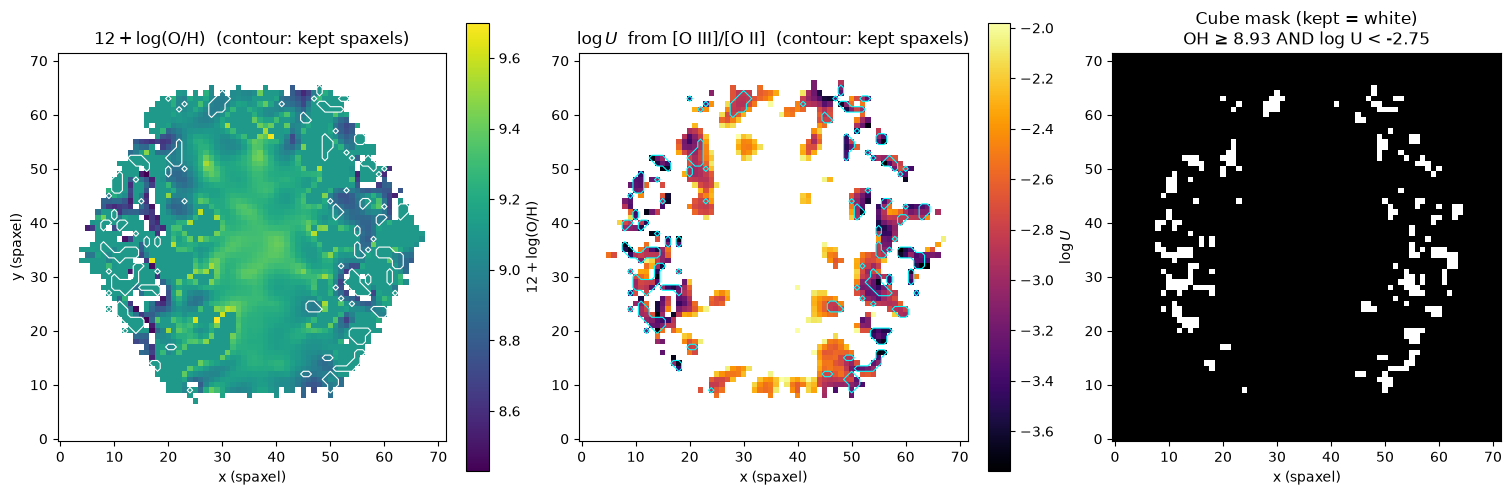

In [12]:
# Show which spaxels the mask keeps, overlaid with the two selection criteria for context.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axes[0].imshow(np.ma.masked_where(~oh_valid, OH), origin="lower", cmap="viridis")
axes[0].contour(include_spaxel, levels=[0.5], colors="white", linewidths=0.8)
axes[0].set_title(r"$12+\log(\mathrm{O/H})$  (contour: kept spaxels)")
fig.colorbar(im0, ax=axes[0], label=r"$12+\log(\mathrm{O/H})$")

im1 = axes[1].imshow(np.ma.masked_invalid(logU_map_o), origin="lower", cmap="inferno")
axes[1].contour(include_spaxel, levels=[0.5], colors="cyan", linewidths=0.8)
axes[1].set_title(r"$\log U$  from [O III]/[O II]  (contour: kept spaxels)")
fig.colorbar(im1, ax=axes[1], label=r"$\log U$")

axes[2].imshow(include_spaxel.astype(int), origin="lower", cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Cube mask (kept = white)\nOH ≥ {SOLAR_OH} AND log U < {LOGU_LIMIT}")

for ax in axes:
    ax.set_xlabel("x (spaxel)")
axes[0].set_ylabel("y (spaxel)")
plt.show()